# ¡Hola Abraham! 😊

Mi nombre es **Alejandro Castellanos** y hoy tengo el placer de ser el revisor de tu proyecto.

Voy a revisar todo tu código con detalle, buscando tanto los puntos fuertes como aquellos en los que podrías mejorar. Te dejaré comentarios a lo largo del notebook, destacando lo que has hecho bien y sugiriendo ajustes donde sea necesario. Si encuentro algún error, no te preocupes, te lo haré saber de forma clara y te daré información útil para que puedas corregirlo en la próxima iteración. Si en algún punto tienes comentarios, siéntete libre de dejarlos también.


Encontrarás mis comentarios específicos dentro de cajas verdes, amarillas o rojas, es muy importante que no muevas, modifiques o borres mis comentarios, con el fin de tener un seguimiento adecuado de tu proceso:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

A continuación te dejaré un comentario general con mi valoración del proyecto. **¡Mi objetivo es que sigas aprendiendo y mejorando con cada paso!**


-----

<div class="alert alert-block alert-success">
<b>Comentario General del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Abraham completaste todas las tareas propuestas para el proyecto de manera sobresaliente. Demostraste un excelente manejo de las herramientas de manipulación y visualización de datos.

Como sugerencia para fortalecer aún más tu análisis estadístico, sería conveniente incorporar la prueba de Levene antes de realizar comparaciones de medias, ya que esto asegurará que tus resultados sean más robustos y confiables.

Continúa desarrollando estas habilidades, ya que serán claves en futuros proyectos.

Éxitos en tu próximo sprint 🚀

*Estado del Proyecto:* **Aprobado**

</div>

-----

# La duración promedio de los viajes al aeropuerto y su relación con el clima

Primero obtengo los datos y realizo una exploración de lo que se puede saber a partir de ellos.

In [1]:
#importo librerias necesarias
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats as st

In [2]:
#se convierten los datos a DataFrame y se observa su estructura
viajes = pd.read_csv('/datasets/project_sql_result_04.csv')
compañias = pd.read_csv('/datasets/project_sql_result_01.csv')

viajes.info()
print('\n')
compañias.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


de esto se puede observar que no hay datos nulos, y que el tipo de dato es adecuado para el análisis.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Muy buen trabajo importando las librerías y los datos del proyecto. Adicionalmente usaste correctamente la función `info`, esto te permite hacer una primera revisión de los datos, su estructura y contenido. 

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Te recomiendo también hacer una validación de datos duplicados, con el fin de evitar errores o sesgos en en análisis de los datos

</div>
</div>

In [3]:
# se obtienen los 10 barrios donde terminan más viajes
top10_barrios = (viajes.sort_values('average_trips', ascending= False)).head(10)
print(top10_barrios)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


Ahora, para mostrar los datos solicitados se presentan graficos donde se aprecien las empresas con su numero de viajes y los 10 barrios con más finalizaciones.

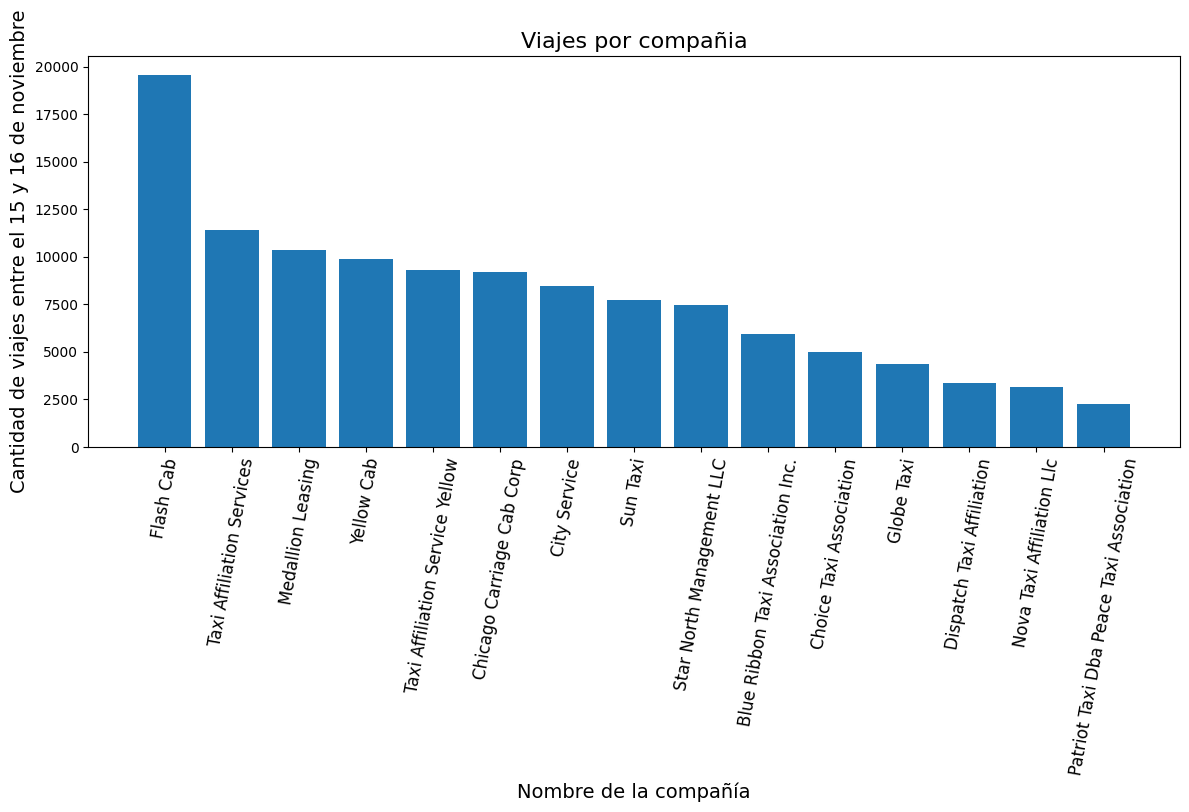

In [4]:


#al ser muchas compañias de taxis, se acotan a las primeras 15 con màs viajes para que el gràfico sea legible.
top15_compañias = (compañias.sort_values('trips_amount', ascending= False)).head(15)

#se usa la libreria matplotlib por su personalización
plt.figure(figsize=(12, 8))
plt.bar(top15_compañias['company_name'], top15_compañias['trips_amount'])
plt.title('Viajes por compañia', fontsize=16)
plt.xlabel('Nombre de la compañía', fontsize=14)
plt.ylabel('Cantidad de viajes entre el 15 y 16 de noviembre', fontsize=14)
plt.xticks(rotation=80, fontsize=12)
plt.tight_layout()
plt.show()




En el anterior gráfico se aprecia que 'Flash Cab' es la compañia màs usada, por mucho. El resto es muy competido hasta 'Blue Ribbon Taxi Association' donde comiensa a bajar la cantidad de viajes.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

¡Muy buen trabajo con la gráfica! En efecto se observa que Flash Cab lidera en volumen de viajes, lo que sugiere una fuerte concentración del mercado. Esto puede estar relacionado con su cobertura, cantidad de vehículos o buenas estrategias comerciales.

</div>

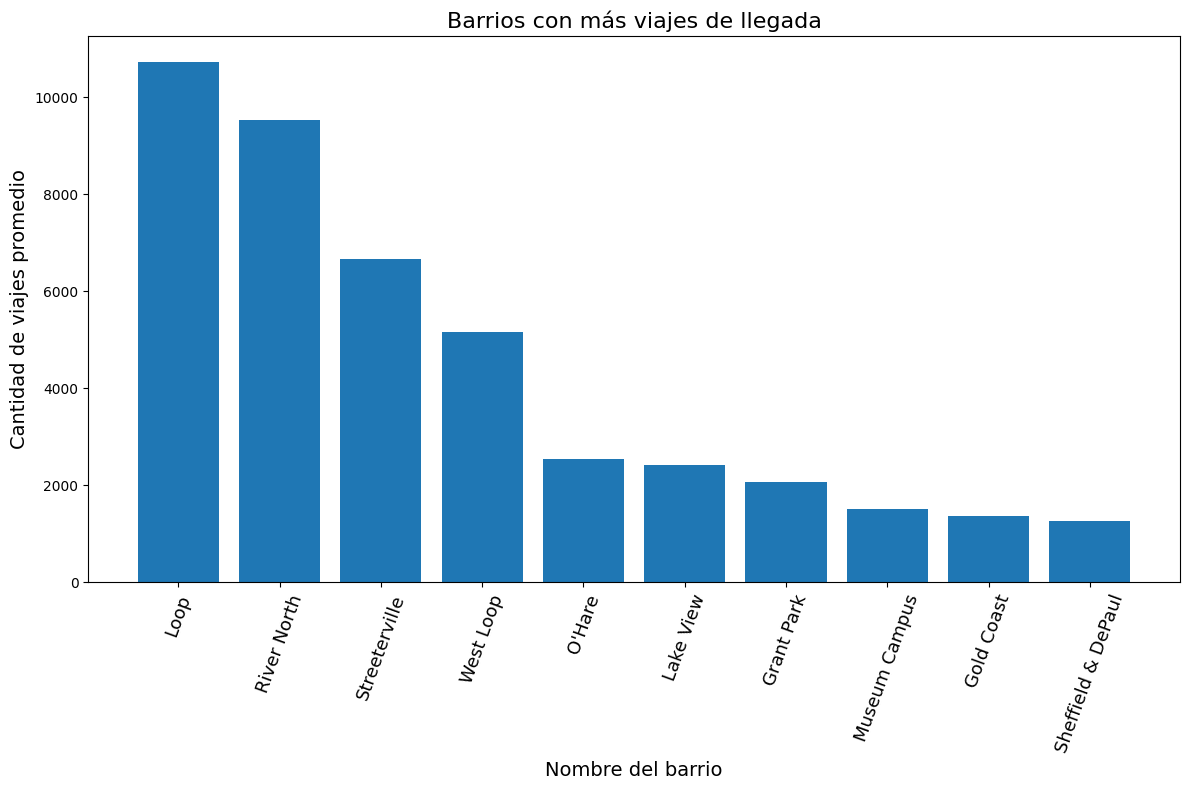

In [5]:
#se presenta la gráfica de los 10 barrios con más finalizaciones de viajes
plt.figure(figsize=(12, 8))
plt.bar(top10_barrios['dropoff_location_name'], top10_barrios['average_trips'])
plt.title('Barrios con más viajes de llegada', fontsize=16)
plt.xlabel('Nombre del barrio', fontsize=14)
plt.ylabel('Cantidad de viajes promedio', fontsize=14)
plt.xticks(rotation=70, fontsize=13)
plt.tight_layout()
plt.show()

Se aprecia que Loop es el barrio con más viajes promedio, por lo que probar la hipotesis del proyecto parace adecuado 

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

¡Buen trabajo obteniendo el Top de barrios! Lograste identificar y jerarquizar bien los de mayor actividad, destacando la diferencia notable con barrios como Loop y River North, que seguramente destacan por su relevancia comercial y turística.

</div>

## Prueba de hipotesis

hipotesis a probar: *"La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos"*
Por lo que:

**Hipótesis nula (H₀)**: La duración promedio de los viajes no cambia los sábados lluviosos

**Hipótesis alternativa (H₁)**: La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos


In [6]:
# Primero cargo el otro data set y observo los datos.
clima = pd.read_csv('/datasets/project_sql_result_07.csv')
print(clima.sample(10))

#cambio el formato de datos a datetime
clima['start_ts'] = pd.to_datetime(clima['start_ts'])

#hago una máscara para sólo tener los datos de los sábados
sabados_clima = clima[clima['start_ts'].dt.dayofweek == 5]
#observè que hay datos anomalos en el dataset, por lo que los elimino, limitando el viaje a 10 min, que ya serìa casi imposible.
sabados_clima = sabados_clima[sabados_clima['duration_seconds'] >= 600]

                 start_ts weather_conditions  duration_seconds
972   2017-11-04 12:00:00               Good            2460.0
267   2017-11-04 02:00:00               Good            2956.0
277   2017-11-18 04:00:00               Good            1737.0
154   2017-11-25 20:00:00               Good            1980.0
543   2017-11-18 06:00:00               Good            1500.0
295   2017-11-18 15:00:00               Good            3660.0
837   2017-11-04 17:00:00                Bad            2520.0
925   2017-11-04 14:00:00               Good            3831.0
271   2017-11-18 12:00:00                Bad            2700.0
1009  2017-11-04 10:00:00               Good            2055.0


In [7]:
#Separo las variables en clima bueno y malo para la comparación en las pruebas estadisticas.
clima_malo = sabados_clima[sabados_clima['weather_conditions'] == 'Bad']
clima_bueno = sabados_clima[sabados_clima['weather_conditions'] == 'Good']


In [8]:
#ahora reviso la catnidad y estructura de los datos que quedan para cada grupo
#shape para ver la cantidad de datos y descibe para la estadistica descriptiva

print(clima_malo['duration_seconds'].shape)
print(clima_malo['duration_seconds'].describe())
print('\n')
print(clima_bueno['duration_seconds'].shape)
print(clima_bueno['duration_seconds'].describe())


(178,)
count     178.000000
mean     2449.084270
std       694.873145
min      1182.000000
25%      1995.000000
50%      2565.500000
75%      2932.000000
max      4980.000000
Name: duration_seconds, dtype: float64


(880,)
count     880.000000
mean     2017.309091
std       739.528556
min      1018.000000
25%      1404.750000
50%      1800.000000
75%      2460.000000
max      7440.000000
Name: duration_seconds, dtype: float64


Una vez visto las estadisticas descriptivas de ambos grupos y comparando sus medias, desviacion estandar y numero de registros,  lo adecuado sería usar una prueba **t de Welch**, pues la diferenia de registros es bastante entre las dos, a pesar de que su desviación estandar es similar. Con un alpha estandar de .05, pues la posibilidad de error es la adecuada.

In [17]:
t_stat, p_value= st.ttest_ind(clima_malo['duration_seconds'], clima_bueno['duration_seconds'], equal_var=False)

print('t stat:', t_stat)
print('p value:', p_value)
print('\n')

alpha = 0.05

if p_value < alpha:
    print("Rechazamos H₀: Hay diferencia significativa entre los dias con lluvia y sin lluvia")
else:
    print("No rechazamos H₀: No hay diferencia significativa entre los dias con lluvia y sin lluvia")

t stat: 7.477690811127809
p value: 1.113653518435732e-12


Rechazamos H₀: Hay diferencia significativa entre los dias con lluvia y sin lluvia


# Conclusiones
¿Qué significan los datos?
El numero del **p value** es **1.113653518435732e-12** que en decimales, eso se ve así: 0.0000000000011136
Lo que implica que es mucho menor al alpha de .05, lo que significa que el margen de error es muy pequeño.

el t stat de **7.477690811127809** nos dice que la diferencia entre las medias es 7.47 veces más grande que el error estándar de la muestra.
Una evidencia fuerte y con un grado de error minusculo.
Volviendo a los datos de las muestras, se observa que:
Días sin lluvia: Mediana = 1800s (30 min).
Días con lluvia: Mediana = 2565s (42.7 min).
Diferencia de medianas: 12.7 minutos.

La diferencia entre las medianas (12.7 min) es mucho mayor que la diferencia entre las medias (7.2 min).
Lo que significa que, en los días sin lluvia, la media (2017s) está siendo inflada por algunos viajes muy largos (el máximo de 7440s), pero la mayoría de la gente llega en 30 min.
En cambio, el sábado lluvioso, el retraso es sistémico: el viaje típico sube casi 13 minutos. **La lluvia no solo causa retrasos aislados, sino que mueve a toda la población hacia tiempos más lentos**

En conclusión se puede decir que: **La lluvia no solo afecta el tráfico de forma real, sino que lo hace sustancialmente, aumentando los tiempos de traslado en más de un 20% los sábados**


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Abraham aplicaste correctamente la prueba de hipótesis comparando la distribución de dos muestras independientes e interpretando de manera acertada el *p-value* obtenido y su relación con la hipótesis nula, logrando comprobar que el clima sí afecta la duración de los viajes en Taxi


<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Te recomiendo realizar previamente una prueba de [Levene](https://www.educaopen.com/digital-lab/blog/educacion-digital/prueba-de-levene) para evaluar la igualdad de las varianzas, lo que te permitirá configurar adecuadamente el parámetro **equal_var** en la función `ttest_ind`. Esto te brindará una interpretación más precisa de los resultados además garantizará que la *prueba t* sea estadísticamente válida.

</div>
</div>